<a href="https://colab.research.google.com/github/toche7/AI_ITM/blob/main/LabFeatureEngineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab Feature Engineering: การปรับขนาดฟีเจอร์และการสร้างฟีเจอร์พหุนาม

สมุดบันทึกนี้สาธิตขั้นตอนการประมวลผลล่วงหน้าที่สำคัญสองประการในการเรียนรู้ของเครื่องจักร: **การปรับขนาดฟีเจอร์ (Feature Scaling)** และ **การสร้างฟีเจอร์พหุนาม (Polynomial Feature Engineering)**

## 1. การปรับขนาดฟีเจอร์ (Feature Scaling)

การปรับขนาดฟีเจอร์เป็นวิธีการที่ใช้ในการทำให้นอร์มอลไลซ์ช่วงของตัวแปรอิสระหรือฟีเจอร์ของข้อมูล ในการประมวลผลข้อมูล ยังเป็นที่รู้จักกันในชื่อการทำใหข้อมูลเป็นมาตรฐาน (data normalization) และโดยทั่วไปจะดำเนินการในขั้นตอนการประมวลผลข้อมูลล่วงหน้า (data preprocessing) ช่วยเร่งความเร็วของอัลกอริทึมที่ใช้การไล่ระดับลง (gradient descent) และอาจมีความสำคัญอย่างยิ่งสำหรับอัลกอริทึมที่คำนวณระยะทาง เช่น K-Nearest Neighbors หรือ Support Vector Machines

เราจะสาธิตเทคนิคการปรับขนาดทั่วไปสองวิธี:

*   **StandardScaler (การทำให้นอร์มอลไลซ์แบบ Z-score)**: ปรับขนาดฟีเจอร์ให้มีค่าเฉลี่ยเป็นศูนย์และความแปรปรวนเป็นหนึ่ง
*   **MinMaxScaler**: ปรับขนาดฟีเจอร์ให้อยู่ในช่วงที่กำหนด โดยทั่วไปคือ [0, 1]

Original Data Statistics:


,Feature_1_Large_Range,Feature_2_Small_Range
count,100.000000,100.000000
mean,481.043941,48.696853
std,305.489801,28.540946
min,5.522117,1.658783
25%,235.427699,22.539878
50%,444.007501,49.892797
75%,763.330581,73.564316
max,985.650454,98.688694


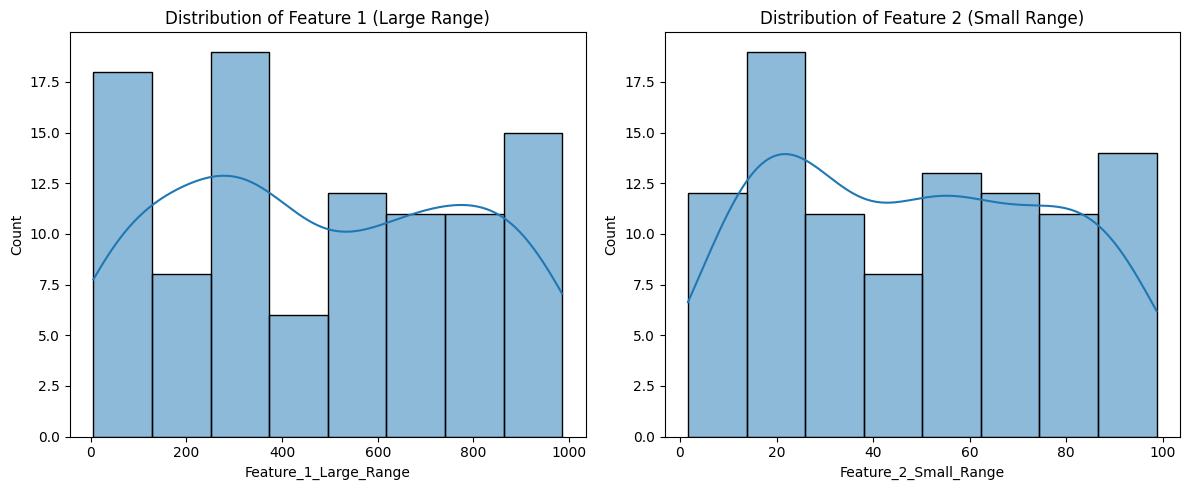

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Generate a synthetic dataset
np.random.seed(42)
X = np.random.rand(100, 2) * 100 # Features ranging from 0 to 100
X[:, 0] = X[:, 0] * 10 # Make the first feature have a larger range

df = pd.DataFrame(X, columns=['Feature_1_Large_Range', 'Feature_2_Small_Range'])

print("Original Data Statistics:")
display(df.describe())

# Visualize original data distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(df['Feature_1_Large_Range'], kde=True, ax=axes[0])
axes[0].set_title('Distribution of Feature 1 (Large Range)')
sns.histplot(df['Feature_2_Small_Range'], kde=True, ax=axes[1])
axes[1].set_title('Distribution of Feature 2 (Small Range)')
plt.tight_layout()
plt.show()

StandardScaler Data Statistics:


,Feature_1_StandardScaled,Feature_2_StandardScaled
count,1.000000e+02,1.000000e+02
mean,-1.332268e-16,-8.437695e-17
std,1.005038e+00,1.005038e+00
min,-1.564430e+00,-1.656394e+00
25%,-8.080584e-01,-9.210889e-01
50%,-1.218470e-01,4.211385e-02
75%,9.287012e-01,8.756802e-01
max,1.660116e+00,1.760407e+00


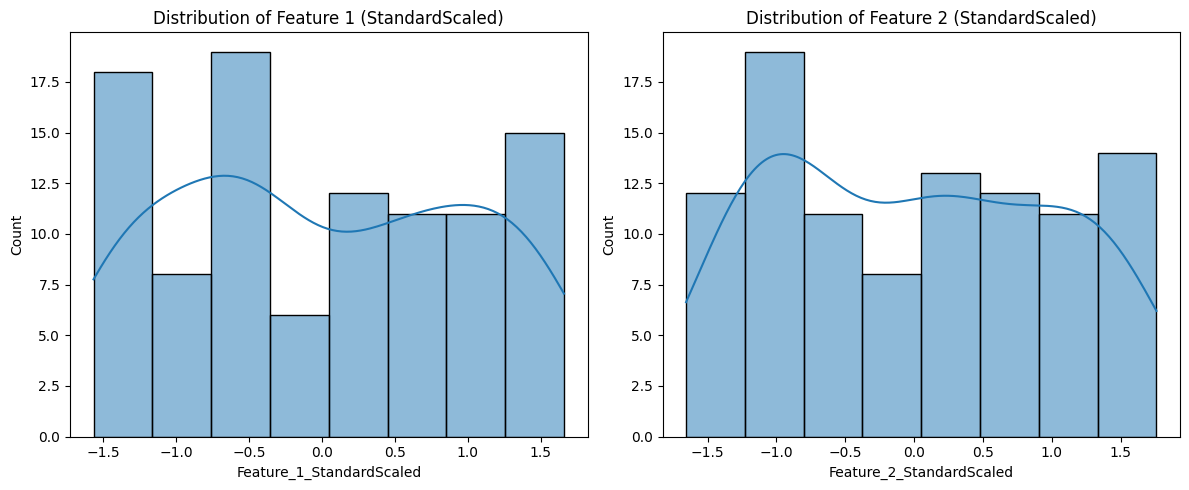

In [5]:
# Apply StandardScaler
scaler_std = StandardScaler()
X_scaled_std = scaler_std.fit_transform(X)
df_scaled_std = pd.DataFrame(X_scaled_std, columns=['Feature_1_StandardScaled', 'Feature_2_StandardScaled'])

print("StandardScaler Data Statistics:")
display(df_scaled_std.describe())

# Visualize StandardScaler data distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(df_scaled_std['Feature_1_StandardScaled'], kde=True, ax=axes[0])
axes[0].set_title('Distribution of Feature 1 (StandardScaled)')
sns.histplot(df_scaled_std['Feature_2_StandardScaled'], kde=True, ax=axes[1])
axes[1].set_title('Distribution of Feature 2 (StandardScaled)')
plt.tight_layout()
plt.show()

MinMaxScaler Data Statistics:


,Feature_1_MinMaxScaled,Feature_2_MinMaxScaled
count,100.000000,100.000000
mean,0.485163,0.484779
std,0.311683,0.294146
min,0.000000,0.000000
25%,0.234567,0.215203
50%,0.447375,0.497105
75%,0.773173,0.741066
max,1.000000,1.000000


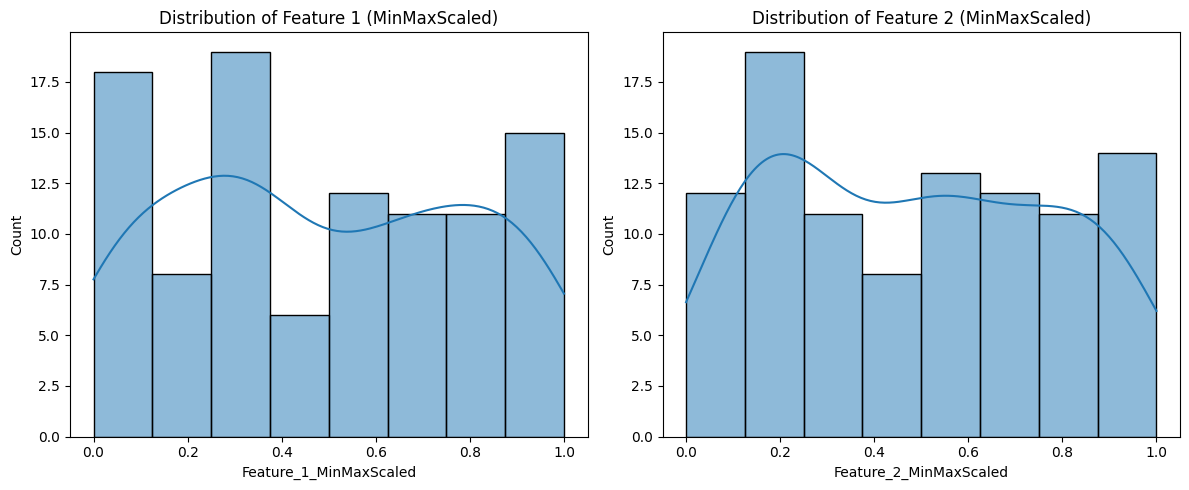

In [6]:
# Apply MinMaxScaler
scaler_minmax = MinMaxScaler()
X_scaled_minmax = scaler_minmax.fit_transform(X)
df_scaled_minmax = pd.DataFrame(X_scaled_minmax, columns=['Feature_1_MinMaxScaled', 'Feature_2_MinMaxScaled'])

print("MinMaxScaler Data Statistics:")
display(df_scaled_minmax.describe())

# Visualize MinMaxScaler data distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(df_scaled_minmax['Feature_1_MinMaxScaled'], kde=True, ax=axes[0])
axes[0].set_title('Distribution of Feature 1 (MinMaxScaled)')
sns.histplot(df_scaled_minmax['Feature_2_MinMaxScaled'], kde=True, ax=axes[1])
axes[1].set_title('Distribution of Feature 2 (MinMaxScaled)')
plt.tight_layout()
plt.show()

## 2. การสร้างฟีเจอร์ (Feature Engineering): ฟีเจอร์พหุนาม

การสร้างฟีเจอร์คือกระบวนการของการใช้ความรู้เฉพาะด้านเพื่อดึงฟีเจอร์จากข้อมูลดิบ ฟีเจอร์เหล่านี้สามารถนำไปใช้เพื่อปรับปรุงประสิทธิภาพของอัลกอริทึมการเรียนรู้ของเครื่องจักรได้ เทคนิคทั่วไปอย่างหนึ่งคือการสร้างฟีเจอร์พหุนาม ซึ่งสามารถจับความสัมพันธ์ที่ไม่เป็นเชิงเส้นระหว่างฟีเจอร์และตัวแปรเป้าหมายได้

เราจะใช้ `PolynomialFeatures` จาก `sklearn.preprocessing` เพื่อสร้างฟีเจอร์ใหม่ที่เป็นการรวมกันแบบพหุนามของฟีเจอร์ที่มีอยู่

In [7]:
from sklearn.preprocessing import PolynomialFeatures

# Generate polynomial features up to degree 2 for the original data
poly = PolynomialFeatures(degree=2, include_bias=False) # include_bias=False avoids adding a column of all ones
X_poly = poly.fit_transform(X)

# Get feature names for the polynomial features
poly_feature_names = poly.get_feature_names_out(['Feature_1', 'Feature_2'])
df_poly = pd.DataFrame(X_poly, columns=poly_feature_names)

print("Original Feature Names:", df.columns.tolist())
print("Generated Polynomial Feature Names:", poly_feature_names.tolist())

print("\nFirst 5 rows of Original Data:")
display(df.head())

print("\nFirst 5 rows of Polynomial Features (degree 2):")
display(df_poly.head())

# You can also generate higher degree polynomial features
poly_degree_3 = PolynomialFeatures(degree=3, include_bias=False)
X_poly_degree_3 = poly_degree_3.fit_transform(X)
poly_feature_names_degree_3 = poly_degree_3.get_feature_names_out(['Feature_1', 'Feature_2'])
df_poly_degree_3 = pd.DataFrame(X_poly_degree_3, columns=poly_feature_names_degree_3)

print("\nGenerated Polynomial Feature Names (degree 3):")
print(poly_feature_names_degree_3.tolist())

print("\nFirst 5 rows of Polynomial Features (degree 3):")
display(df_poly_degree_3.head())

Original Feature Names: ['Feature_1_Large_Range', 'Feature_2_Small_Range']
Generated Polynomial Feature Names: ['Feature_1', 'Feature_2', 'Feature_1^2', 'Feature_1 Feature_2', 'Feature_2^2']

First 5 rows of Original Data:


,Feature_1_Large_Range,Feature_2_Small_Range
0,374.540119,95.071431
1,731.993942,59.865848
2,156.018640,15.599452
3,58.083612,86.617615
4,601.115012,70.807258



First 5 rows of Polynomial Features (degree 2):


,Feature_1,Feature_2,Feature_1^2,Feature_1 Feature_2,Feature_2^2
0,374.540119,95.071431,140280.300626,35608.064931,9038.576924
1,731.993942,59.865848,535815.130849,43821.438365,3583.919807
2,156.018640,15.599452,24341.816166,2433.805298,243.342904
3,58.083612,86.617615,3373.706003,5031.063932,7502.611155
4,601.115012,70.807258,361339.257343,42563.305592,5013.667754



Generated Polynomial Feature Names (degree 3):
['Feature_1', 'Feature_2', 'Feature_1^2', 'Feature_1 Feature_2', 'Feature_2^2', 'Feature_1^3', 'Feature_1^2 Feature_2', 'Feature_1 Feature_2^2', 'Feature_2^3']

First 5 rows of Polynomial Features (degree 3):


,Feature_1,Feature_2,Feature_1^2,Feature_1 Feature_2,Feature_2^2,Feature_1^3,Feature_1^2 Feature_2,Feature_1 Feature_2^2,Feature_2^3
0,374.540119,95.071431,140280.300626,35608.064931,9038.576924,5.254060e+07,1.333665e+07,3.385310e+06,859310.439135
1,731.993942,59.865848,535815.130849,43821.438365,3583.919807,3.922134e+08,3.207703e+07,2.623408e+06,214554.399915
2,156.018640,15.599452,24341.816166,2433.805298,243.342904,3.797777e+06,3.797190e+05,3.796603e+04,3796.015955
3,58.083612,86.617615,3373.706003,5031.063932,7502.611155,1.959570e+05,2.922224e+05,4.357788e+05,649858.281357
4,601.115012,70.807258,361339.257343,42563.305592,5013.667754,2.172065e+08,2.558544e+07,3.013791e+06,355004.065098


## 3. การประยุกต์ใช้กับโมเดลการเรียนรู้ของเครื่องจักร

เพื่อแสดงให้เห็นถึงผลกระทบในทางปฏิบัติของการปรับขนาดฟีเจอร์และการสร้างฟีเจอร์พหุนาม เราจะฝึกโมเดลการถดถอยเชิงเส้นอย่างง่าย (Linear Regression) กับชุดข้อมูลสังเคราะห์ของเราโดยใช้:

1.  **ฟีเจอร์ต้นฉบับ**
2.  **ฟีเจอร์ที่แปลงด้วย StandardScaler**
3.  **ฟีเจอร์พหุนาม** (ดีกรี 2)

เราจะประเมินประสิทธิภาพโดยใช้คะแนน R-squared

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# Create a synthetic target variable 'y'
# Let's make 'y' depend on Feature_1 linearly, and Feature_2 with some non-linearity,
# so polynomial features might help.
np.random.seed(42)
y = 0.5 * X[:, 0] + 0.2 * X[:, 1]**2 + 5 * np.random.randn(100) # y = 0.5 * Feature_1 + 0.2 * Feature_2^2 + noise

# --- 1. Model with Original Features ---
print("\n--- Model with Original Features ---")
X_train_orig, X_test_orig, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model_orig = LinearRegression()
model_orig.fit(X_train_orig, y_train)
y_pred_orig = model_orig.predict(X_test_orig)
r2_orig = r2_score(y_test, y_pred_orig)
mse_orig = mean_squared_error(y_test, y_pred_orig)
print(f"R-squared (Original): {r2_orig:.4f}")
print(f"MSE (Original): {mse_orig:.4f}")

# --- 2. Model with Standard Scaled Features ---
print("\n--- Model with Standard Scaled Features ---")
# Use the already scaled X_scaled_std (or re-scale X for train/test split consistency)
# It's crucial to fit scaler ONLY on training data and transform both train/test

X_train_std, X_test_std, y_train_std, y_test_std = train_test_split(X, y, test_size=0.3, random_state=42)

scaler_std_model = StandardScaler()
X_train_std_scaled = scaler_std_model.fit_transform(X_train_std)
X_test_std_scaled = scaler_std_model.transform(X_test_std)

model_std = LinearRegression()
model_std.fit(X_train_std_scaled, y_train_std)
y_pred_std = model_std.predict(X_test_std_scaled)
r2_std = r2_score(y_test_std, y_pred_std)
mse_std = mean_squared_error(y_test_std, y_pred_std)
print(f"R-squared (Standard Scaled): {r2_std:.4f}")
print(f"MSE (Standard Scaled): {mse_std:.4f}")

# --- 3. Model with Polynomial Features (degree 2) ---
print("\n--- Model with Polynomial Features (degree 2) ---")
# Generate polynomial features on the full X first, then split
poly_model = PolynomialFeatures(degree=2, include_bias=False)
X_poly_model = poly_model.fit_transform(X)

X_train_poly, X_test_poly, y_train_poly, y_test_poly = train_test_split(X_poly_model, y, test_size=0.3, random_state=42)

model_poly = LinearRegression()
model_poly.fit(X_train_poly, y_train_poly)
y_pred_poly = model_poly.predict(X_test_poly)
r2_poly = r2_score(y_test_poly, y_pred_poly)
mse_poly = mean_squared_error(y_test_poly, y_pred_poly)
print(f"R-squared (Polynomial Degree 2): {r2_poly:.4f}")
print(f"MSE (Polynomial Degree 2): {mse_poly:.4f}")


--- Model with Original Features ---
R-squared (Original): 0.9477
MSE (Original): 17118.7719

--- Model with Standard Scaled Features ---
R-squared (Standard Scaled): 0.9477
MSE (Standard Scaled): 17118.7719

--- Model with Polynomial Features (degree 2) ---
R-squared (Polynomial Degree 2): 1.0000
MSE (Polynomial Degree 2): 14.5679


### สรุปผลลัพธ์:

*   **ฟีเจอร์ต้นฉบับ (Original Features):** ค่า `R-squared` น่าจะต่ำกว่า ซึ่งบ่งชี้ว่าโมเดลเชิงเส้นไม่สามารถจับความสัมพันธ์ที่ไม่เป็นเชิงเส้นใน `y` ได้อย่างสมบูรณ์
*   **ฟีเจอร์ที่ปรับขนาดด้วยมาตรฐาน (Standard Scaled Features):** ค่า `R-squared` อาจคล้ายกับต้นฉบับหากโมเดลเป็นการถดถอยเชิงเส้น แต่การปรับขนาดมีความสำคัญต่ออัลกอริทึมอื่นๆ อีกมากมาย (เช่น SVM, K-NN, โครงข่ายประสาทเทียม)
*   **ฟีเจอร์พหุนาม (Polynomial Features, ดีกรี 2):** ค่า `R-squared` ควรจะสูงขึ้นอย่างมีนัยสำคัญ ซึ่งแสดงให้เห็นว่าฟีเจอร์พหุนามสามารถช่วยให้โมเดลเชิงเส้นเหมาะสมกับข้อมูลที่ไม่เป็นเชิงเส้นได้ดีขึ้นโดยการแนะนำเทอมที่มีลำดับสูงกว่า (เช่น `Feature_2^2` ใน `y` สังเคราะห์ของเรา)

การสาธิตนี้เน้นย้ำว่าการเลือกขั้นตอนการประมวลผลล่วงหน้าที่เหมาะสมสามารถส่งผลกระทบอย่างมากต่อประสิทธิภาพของโมเดล โดยเฉพาะอย่างยิ่งเมื่อจัดการกับข้อมูลที่มีมาตราส่วนที่แตกต่างกันหรือความสัมพันธ์ที่ไม่เป็นเชิงเส้น